# 03. Exploración visual del dataset APTOS 2019

Este notebook realiza una exploración visual de las particiones
experimentales previamente congeladas de APTOS 2019.

El análisis tiene como objetivos:

- verificar visualmente la representación de las cinco clases;
- observar la variabilidad de iluminación, contraste y color;
- analizar la presencia de regiones negras alrededor del campo retinal;
- observar diferencias en escala, encuadre y posición de la retina;
- identificar casos de baja calidad visual;
- obtener evidencia para definir posteriormente el preprocesamiento común.

En esta etapa no se modifican las imágenes ni las particiones
Train, Validation y Test.

## 1. Configuración del entorno, rutas y carga de particiones

Configuración de librerías y rutas principales del dataset. Se carga el archivo maestro de particiones experimentales (`aptos2019_splits.csv`) congelado en la fase de preparación para verificar las dimensiones de los subconjuntos Train, Validation y Test.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)
RAW_DIR = (
    APTOS_ROOT
    / "raw"
)
TRAIN_IMAGES_DIR = (
    RAW_DIR
    / "train_images"
)
METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)
SPLITS_PATH = (
    METADATA_DIR
    / "aptos2019_splits.csv"
)

splits_df = pd.read_csv(
    SPLITS_PATH
)

print(
    "Registros:",
    len(splits_df)
)
print(
    "\nDistribución por split:"
)
print(
    splits_df[
        "experimental_split"
    ].value_counts()
)

Registros: 3487

Distribución por split:
experimental_split
train         2440
test           524
validation     523
Name: count, dtype: int64


## 2. Exploración visual de las categorías diagnósticas

Se inspeccionan muestras representativas de las cinco categorías de
Retinopatía Diabética pertenecientes exclusivamente al conjunto Train.

Esta exploración permite observar la variabilidad visual presente dentro
de cada clase antes de definir el procedimiento de preprocesamiento y
aumento de datos.

La selección de imágenes utiliza una semilla fija para garantizar que
la visualización sea reproducible.

In [2]:
class_names = {
    0: "Sin RD",
    1: "Leve",
    2: "Moderada",
    3: "Severa",
    4: "Proliferativa"
}

train_df = (
    splits_df[
        splits_df["experimental_split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Imágenes Train:",
    len(train_df)
)
print(
    "\nDistribución:"
)
print(
    train_df["diagnosis"]
    .value_counts()
    .sort_index()
)

Imágenes Train: 2440

Distribución:
diagnosis
0    1257
1     236
2     645
3     118
4     184
Name: count, dtype: int64


Se genera una cuadrícula visual con cuatro imágenes aleatorias por cada categoría diagnóstica del conjunto de entrenamiento para evaluar las características morfológicas, variaciones de iluminación y artefactos de adquisición.

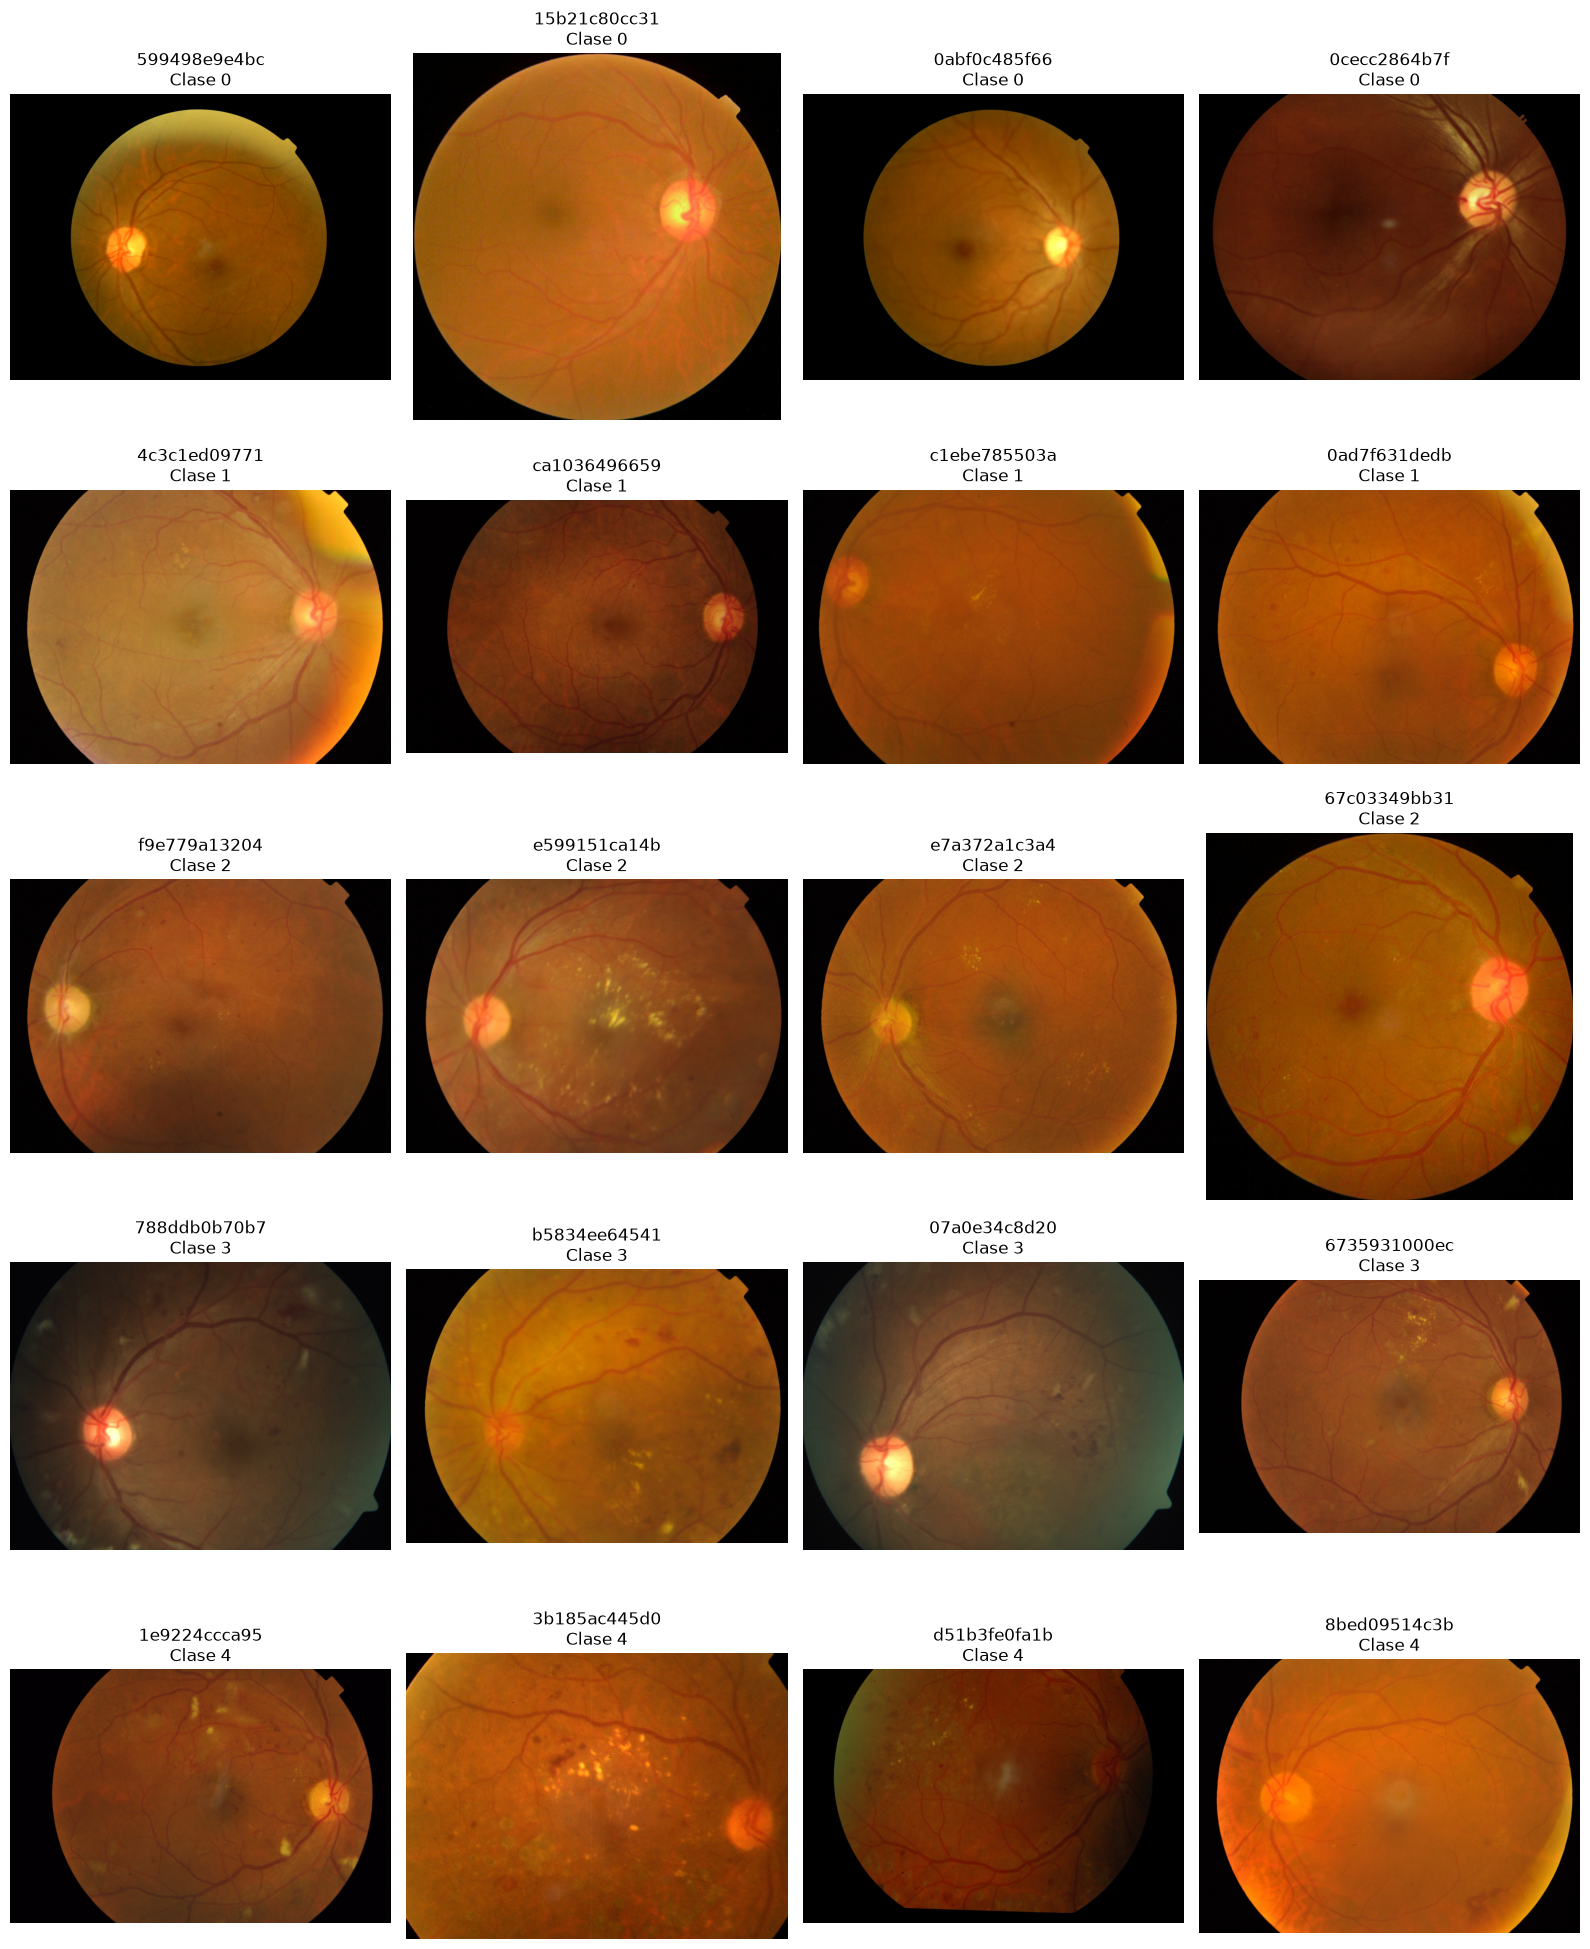

In [3]:
random_seed = 42
samples_per_class = 4

fig, axes = plt.subplots(
    nrows=len(class_names),
    ncols=samples_per_class,
    figsize=(16, 20)
)

for diagnosis in sorted(class_names.keys()):
    class_df = train_df[
        train_df["diagnosis"] == diagnosis
    ]
    sample_df = class_df.sample(
        n=samples_per_class,
        random_state=random_seed
    )
    for col, (_, row) in enumerate(
        sample_df.iterrows()
    ):
        image_path = (
            APTOS_ROOT
            / row["image_path"]
        )
        with Image.open(image_path) as img:
            image = np.array(
                img.convert("RGB")
            )
        axes[
            diagnosis,
            col
        ].imshow(image)
        axes[
            diagnosis,
            col
        ].axis("off")
        axes[
            diagnosis,
            col
        ].set_title(
            f"{row['id_code']}\n"
            f"Clase {diagnosis}"
        )
    axes[
        diagnosis,
        0
    ].set_ylabel(
        class_names[diagnosis],
        fontsize=12
    )

plt.tight_layout()
plt.show()

### 2.1. Hallazgos de la exploración visual en Train

La inspección visual del conjunto Train evidencia una variabilidad
considerable en las condiciones de adquisición de las retinografías.

Se observan diferencias en:

- tamaño y posición del campo retinal;
- extensión de las regiones negras periféricas;
- iluminación, brillo, contraste y tonalidad;
- escala aparente de la retina;
- nitidez y exposición;
- apariencia visual dentro de una misma categoría diagnóstica.

Las clases de mayor severidad presentan en varias muestras lesiones más
evidentes, mientras que las diferencias visuales entre las categorías
Sin RD y Leve pueden ser más sutiles.

Estas observaciones refuerzan la necesidad de definir posteriormente un
preprocesamiento común que reduzca la variabilidad no clínica sin alterar
la información anatómica relevante.

## 3. Comparación visual entre particiones experimentales

Se inspeccionan muestras aleatorias de Train, Validation y Test para
comprobar cualitativamente que las tres particiones conservan una
variabilidad visual comparable y que el particionamiento estratificado
no produjo subconjuntos visualmente anómalos.

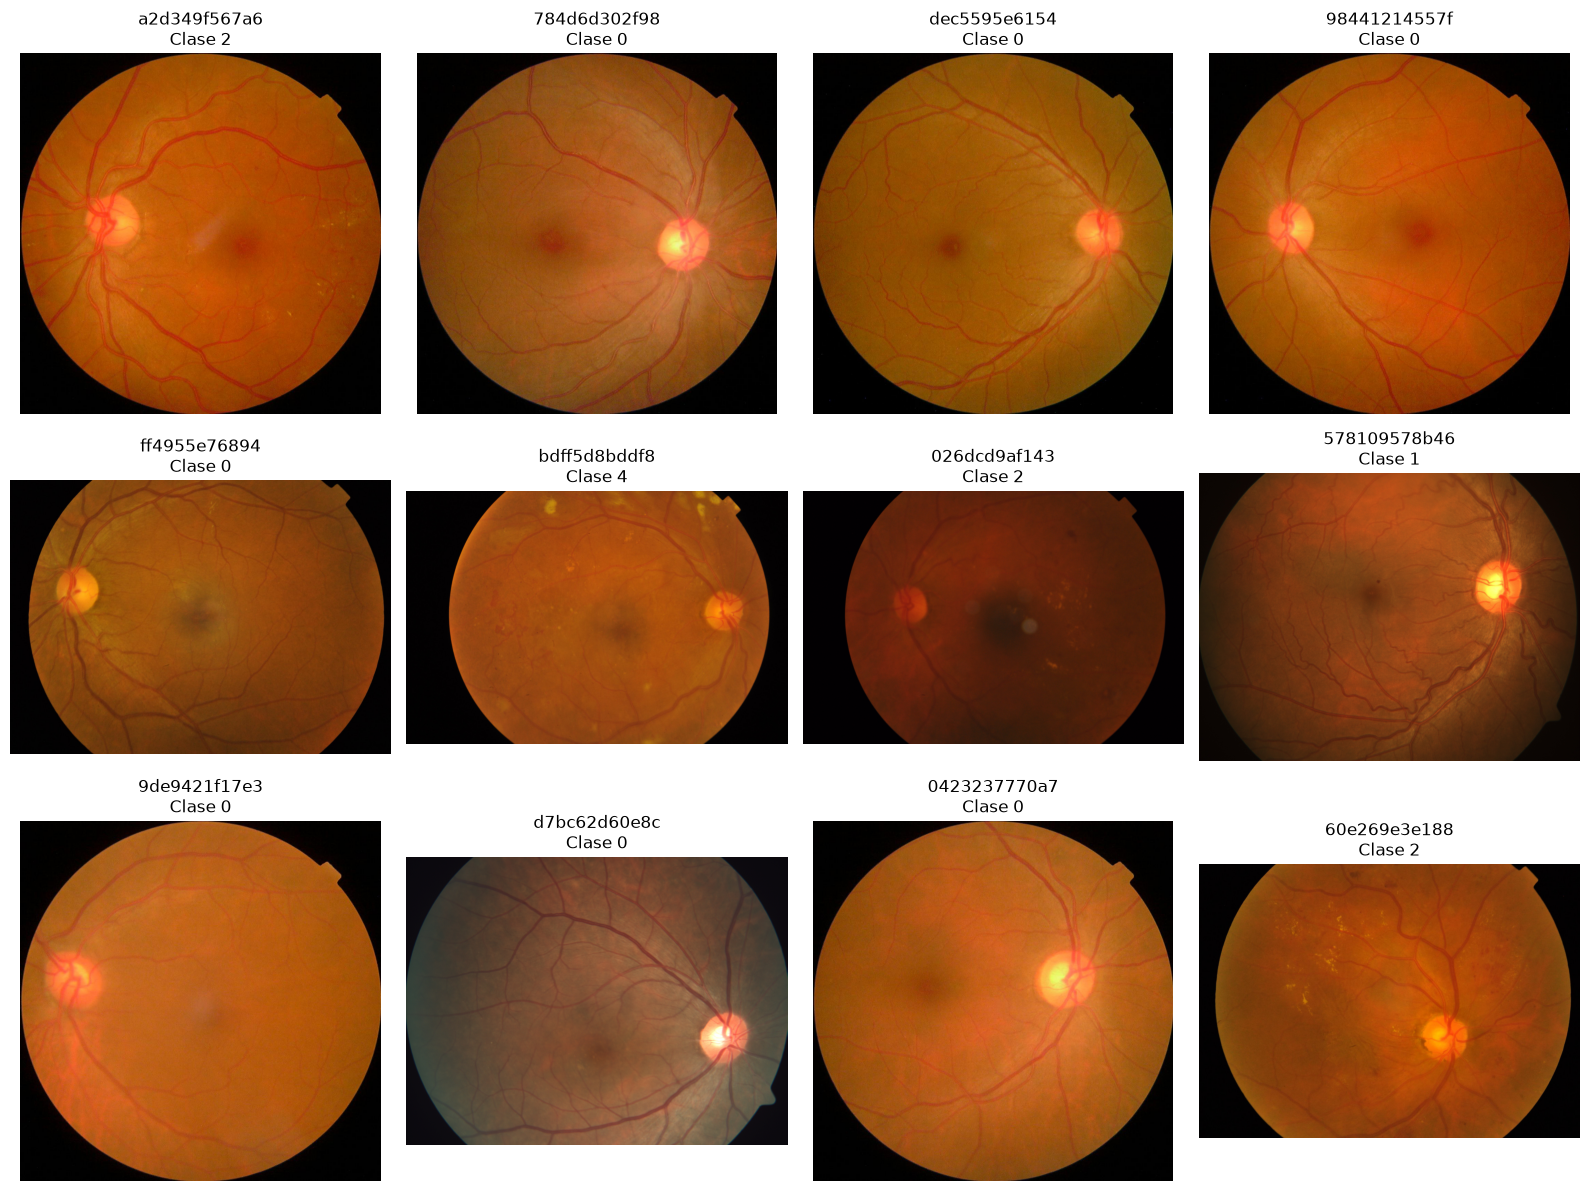

In [4]:
random_seed = 42
samples_per_split = 4
split_order = [
    "train",
    "validation",
    "test"
]

fig, axes = plt.subplots(
    nrows=len(split_order),
    ncols=samples_per_split,
    figsize=(16, 12)
)

for row_index, split_name in enumerate(
    split_order
):
    split_df = (
        splits_df[
            splits_df[
                "experimental_split"
            ] == split_name
        ]
    )
    sample_df = split_df.sample(
        n=samples_per_split,
        random_state=random_seed
    )
    for col, (_, row) in enumerate(
        sample_df.iterrows()
    ):
        image_path = (
            APTOS_ROOT
            / row["image_path"]
        )
        with Image.open(
            image_path
        ) as img:
            image = np.array(
                img.convert("RGB")
            )
        axes[
            row_index,
            col
        ].imshow(image)
        axes[
            row_index,
            col
        ].axis("off")
        axes[
            row_index,
            col
        ].set_title(
            f"{row['id_code']}\n"
            f"Clase {row['diagnosis']}"
        )
    axes[
        row_index,
        0
    ].set_ylabel(
        split_name.upper(),
        fontsize=12
    )

plt.tight_layout()
plt.show()

### 3.1. Hallazgos de la comparación entre particiones

La inspección visual de muestras pertenecientes a Train, Validation y
Test muestra una heterogeneidad comparable entre las tres particiones.

En todos los subconjuntos se observan variaciones en iluminación,
tonalidad, contraste, escala del campo retinal, encuadre y extensión de
las regiones negras periféricas.

No se identifican, en esta inspección cualitativa, características
visuales particulares que diferencien sistemáticamente una partición de
las demás.

Este comportamiento es consistente con el particionamiento aleatorio
estratificado previamente realizado. No obstante, la inspección visual
se complementa a continuación con una caracterización cuantitativa de
brillo, contraste y proporción aproximada de fondo negro.

## 4. Caracterización cuantitativa de brillo, contraste y fondo negro

Se calculan métricas descriptivas simples sobre las imágenes de las tres
particiones experimentales.

Para reducir el efecto de los márgenes negros, el brillo y el contraste
se calculan únicamente sobre los píxeles cuya intensidad es superior a
un umbral mínimo.

Las métricas se utilizan exclusivamente para caracterizar la
heterogeneidad del dataset y orientar posteriormente el diseño del
preprocesamiento.

In [5]:
def calculate_visual_metrics(
    image_path,
    black_threshold=10
):
    with Image.open(image_path) as img:
        image = np.array(
            img.convert("RGB"),
            dtype=np.float32
        )
    # Conversión aproximada a luminancia
    gray = (
        0.299 * image[:, :, 0]
        + 0.587 * image[:, :, 1]
        + 0.114 * image[:, :, 2]
    )
    retinal_mask = (
        gray > black_threshold
    )
    black_fraction = (
        1.0
        - retinal_mask.mean()
    )
    retinal_pixels = gray[
        retinal_mask
    ]
    if len(retinal_pixels) == 0:
        mean_brightness = np.nan
        contrast = np.nan
    else:
        mean_brightness = float(
            retinal_pixels.mean()
        )
        contrast = float(
            retinal_pixels.std()
        )
    return {
        "mean_brightness":
            mean_brightness,
        "contrast":
            contrast,
        "black_fraction":
            float(black_fraction)
    }

Se computan las métricas visuales sobre las 3487 retinografías del conjunto depurado para construir una caracterización cuantitativa completa por partición.

In [6]:
visual_metric_rows = []

for i, (_, row) in enumerate(
    splits_df.iterrows()
):
    image_path = (
        APTOS_ROOT
        / row["image_path"]
    )
    metrics = calculate_visual_metrics(
        image_path
    )
    visual_metric_rows.append(
        {
            "id_code":
                row["id_code"],
            "diagnosis":
                int(row["diagnosis"]),
            "experimental_split":
                row["experimental_split"],
            "mean_brightness":
                metrics[
                    "mean_brightness"
                ],
            "contrast":
                metrics[
                    "contrast"
                ],
            "black_fraction":
                metrics[
                    "black_fraction"
                ]
        }
    )
    processed = (
        i + 1
    )
    if (
        processed % 500 == 0
        or processed == len(splits_df)
    ):
        print(
            f"Procesadas: "
            f"{processed}/"
            f"{len(splits_df)}"
        )

visual_metrics_df = pd.DataFrame(
    visual_metric_rows
)
print(
    "Imágenes caracterizadas:",
    len(visual_metrics_df)
)

Procesadas: 500/3487
Procesadas: 1000/3487
Procesadas: 1500/3487
Procesadas: 2000/3487
Procesadas: 2500/3487
Procesadas: 3000/3487
Procesadas: 3487/3487
Imágenes caracterizadas: 3487


### 4.1. Resumen estadístico de métricas visuales por partición

Cálculo de estadísticas descriptivas completas (media, desviación estándar, percentiles) y comparación directa de medias por split para comprobar que la distribución cuantitativa sea comparable entre Train, Validation y Test.

In [7]:
visual_summary = (
    visual_metrics_df
    .groupby(
        "experimental_split"
    )[
        [
            "mean_brightness",
            "contrast",
            "black_fraction"
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "median",
            "max"
        ]
    )
)
display(
    visual_summary.round(4)
)

visual_means = (
    visual_metrics_df
    .groupby(
        "experimental_split"
    )[
        [
            "mean_brightness",
            "contrast",
            "black_fraction"
        ]
    ]
    .mean()
)
display(
    visual_means.round(4)
)

mean_brightness                                       \
                              mean      std      min   median       max   
experimental_split                                                        
test                       88.3318  20.2913  29.4852  92.4030  146.5982   
train                      87.9668  20.9752  27.5969  91.7596  155.6520   
validation                 87.4026  21.7971  30.0047  90.9866  139.3087   

                   contrast                                   black_fraction  \
                       mean     std     min   median      max           mean   
experimental_split                                                             
test                17.8487  6.0364  7.2531  16.7030  52.3962         0.2298   
train               17.7171  5.7184  6.0057  16.6986  52.4524         0.2374   
validation          18.2171  6.0872  7.6436  17.0964  55.8596         0.2291   

                                                    
                       std     min  median     max  
experimental_split                                  
test                0.1316  0.0044  0.2086  0.5263  
train               0.1360  0.0000  0.2086  0.5295  
validation          0.1365  0.0011  0.2082  0.5282

,mean_brightness,contrast,black_fraction
experimental_split,,,
test,88.3318,17.8487,0.2298
train,87.9668,17.7171,0.2374
validation,87.4026,18.2171,0.2291


### 4.2. Inspección de casos extremos en brillo y fondo negro

Identificación de las diez imágenes con menor intensidad lumínica y de aquellas con mayor proporción de margen negro para evaluar el impacto de los artefactos visuales en el dataset.

In [8]:
print(
    "Imágenes con menor brillo:"
)
display(
    visual_metrics_df
    .nsmallest(
        10,
        "mean_brightness"
    )
)
print(
    "\nImágenes con mayor proporción "
    "de fondo negro:"
)
display(
    visual_metrics_df
    .nlargest(
        10,
        "black_fraction"
    )
)

Imágenes con menor brillo:


,id_code,diagnosis,experimental_split,mean_brightness,contrast,black_fraction
1636,77baa08a1345,2,train,27.596939,7.016615,0.097099
2518,b6304c545f95,2,test,29.485243,10.227900,0.096626
1005,4a7dc013e802,4,test,29.753216,10.686826,0.098315
1737,7eee3d1f1268,0,validation,30.004740,12.600082,0.091990
872,417f408ee8e0,2,train,30.112932,12.071553,0.096478
1264,5b301a6d1ac7,2,train,31.261730,10.791804,0.097252
3194,e821c1b6417a,4,train,31.324306,10.865261,0.096910
1190,5548a7961a3e,1,train,31.625475,10.080163,0.096534
2923,d4583e9525dc,0,train,31.745327,10.800382,0.529536
3093,e1418d28d668,2,train,31.800770,7.961295,0.096112



Imágenes con mayor proporción de fondo negro:


,id_code,diagnosis,experimental_split,mean_brightness,contrast,black_fraction
2923,d4583e9525dc,0,train,31.745327,10.800382,0.529536
1566,7269a1d84a57,0,train,36.405468,15.767312,0.529468
1863,87d46b1cc4e9,0,train,35.120461,11.640062,0.528415
1488,6cb96a6fb029,0,train,37.784874,15.054643,0.528280
176,0d8f60ed9280,0,validation,41.587284,17.318983,0.528227
3396,f819c65b803c,0,train,46.897747,17.608261,0.527672
3163,e5f332efcbc7,0,validation,44.340500,23.562410,0.527437
2823,ccd6dcb2f568,0,validation,35.164680,16.325747,0.527362
1407,66460ecab347,0,train,37.409348,12.236380,0.527353
3048,de2eb5c8aa83,0,train,43.733162,12.247268,0.527349


## 5. Persistencia de los resultados de exploración

Las métricas descriptivas calculadas se almacenan para documentar la
heterogeneidad visual de APTOS 2019 y permitir su comparación con las
imágenes obtenidas después del preprocesamiento.

In [9]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "visual_exploration"
)
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

visual_metrics_df.to_csv(
    RESULTS_DIR
    / "aptos2019_visual_metrics.csv",
    index=False
)
visual_means.to_csv(
    RESULTS_DIR
    / "aptos2019_visual_means_by_split.csv"
)

print(
    "Resultados guardados en:",
    RESULTS_DIR
)

Resultados guardados en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/visual_exploration


## 6. Conclusiones de la exploración visual

La exploración de las 3487 retinografías depuradas confirmó una
heterogeneidad considerable en iluminación, contraste, tonalidad,
encuadre, escala del campo retinal y proporción de regiones negras.

Las medias de brillo, contraste y proporción de fondo negro fueron
similares entre Train, Validation y Test, sin evidenciar diferencias
sistemáticas importantes entre las particiones experimentales.

Se identificaron imágenes con condiciones visuales extremas, incluyendo
baja luminosidad y elevada proporción de fondo negro. Estas observaciones
no se utilizaron como criterios de exclusión, sino como evidencia para
diseñar un procedimiento de preprocesamiento robusto.

A partir de estos resultados, la siguiente etapa definirá un
preprocesamiento común para las arquitecturas candidatas, procurando
reducir regiones no informativas y estandarizar las dimensiones sin
deformar la geometría retinal.